# **Micro-Project: Quantum Confinement in a 1D Infinite Potential Well**

## 1. Computational Approach

The implementation follows seven sequential stages:

1. **Constants & Core Functions:** Define standard constants and standard analytical expressions for $\psi_{n}(x)$ and $E_{n}$.
2. **Quantized Energy Ladder:** Calculate and map discrete energy levels $E_{n}$.
3. **Eigenfunctions & Probability Densities:** Plot spatial wavefunctions $\psi_{n}(x)$ and density distributions $|\psi_{n}(x)|^{2}$.
4. **Numerical Verification of Orthonormality:** Evaluate $\int_{0}^{L}\psi_{n}\psi_{m}dx=\delta_{nm}$ via numerical integration.
5. **Superposition State & Fourier Coefficients:** Project an initial Gaussian wave packet onto the eigenbasis to obtain $c_{n}$ (Eq. 25) and reconstruct $\Psi(x,0)$.
6. **Time Evolution:** Model space-time propagation using the time-dependent Fourier sum $\Psi(x,t)$.
7. **Confinement-Length Dependence:** Evaluate energy scaling $E_{n} \propto 1/L^{2}$ across different well widths $L$.


In [1]:
# Physical constants and core functions
import matplotlib.pyplot as plt
import numpy as np

# Physical constants (SI units)
hbar = 1.054571817e-34  # Reduced Planck constant, J.s
m_e = 9.1093837015e-31  # Electron rest mass, kg
eV = 1.602176634e-19  # 1 electron-volt in Joules

# Confinement length of the infinite well (typical nanoscale quantum-dot size)
L = 1.0e-9  # 1 nanometre


def energy_level(n, L=L, m=m_e):
  # Quantized energy E_n (Joules) of an infinite square well
  return (n**2 * np.pi**2 * hbar**2) / (2 * m * L**2)


def psi_n(x, n, L=L):
  # Normalized spatial eigenfunction psi_n(x)
  return np.sqrt(2.0 / L) * np.sin(n * np.pi * x / L)


print(f'Well width L            = {L*1e9:.2f} nm')
print(f'Ground-state energy E1  = {energy_level(1)/eV:.4f} eV')

Well width L            = 1.00 nm
Ground-state energy E1  = 0.3760 eV


## 2. Quantized Energy Ladder

The energy levels $E_{n}=n^{2}\pi^{2}\hbar^{2}/(2mL^{2})$ are evaluated for $n=1,\dots,8$ for a well width $L = 1.0\text{ nm}$.

### Results & Discussion
* **Ground-State Energy:** $E_1 \approx 0.3760\text{ eV}$.
* **Energy Spectrum ($n=1$ to $8$):** $E_1 = 0.3760\text{ eV}$, $E_2 = 1.5041\text{ eV}$, $E_3 = 3.3843\text{ eV}$, $E_4 = 6.0165\text{ eV}$, $E_5 = 9.4008\text{ eV}$, $E_6 = 13.5371\text{ eV}$, $E_7 = 18.4255\text{ eV}$, $E_8 = 24.0659\text{ eV}$.
* **Discussion:** Energy level spacing increases with $n$ ($E_{n}\propto n^{2}$). In macroscopic systems, levels merge into a continuous band, but at nanoscale dimensions ($L \approx 1\text{ nm}$), quantum confinement produces distinct, widely spaced energy levels.


 n | E_n (eV)
--------------------
 1 |    0.3760
 2 |    1.5041
 3 |    3.3843
 4 |    6.0165
 5 |    9.4008
 6 |   13.5371
 7 |   18.4255
 8 |   24.0659


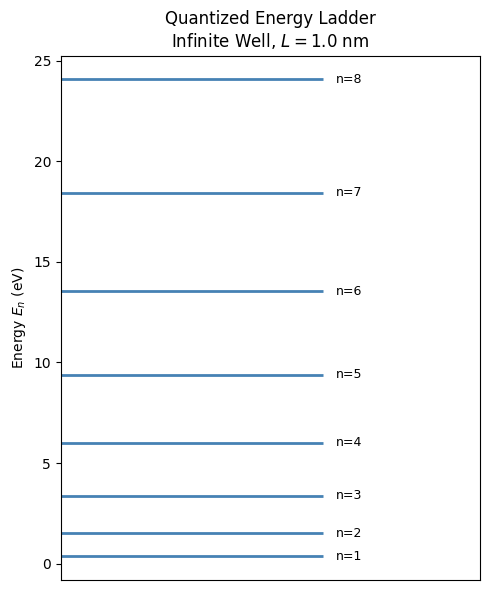

In [2]:
# Quantized energy levels E_n
n_values = np.arange(1, 9)
E_eV = energy_level(n_values) / eV

print(' n | E_n (eV)')
print('-' * 20)
for n, E in zip(n_values, E_eV):
  print(f'{n:2d} | {E:9.4f}')

fig, ax = plt.subplots(figsize=(5, 6))
for n, E in zip(n_values, E_eV):
  ax.hlines(E, 0, 1, color='steelblue', linewidth=2)
  ax.text(1.05, E, f'n={n}', va='center', fontsize=9)

ax.set_xlim(0, 1.6)
ax.set_xticks([])
ax.set_ylabel('Energy $E_n$ (eV)')
ax.set_title(f'Quantized Energy Ladder\nInfinite Well, $L={L*1e9:.1f}$ nm')
plt.tight_layout()
plt.show()

## 3. Spatial Eigenfunctions and Probability Densities

The spatial wavefunctions $\psi_{n}(x)=\sqrt{2/L}\sin(n\pi x/L)$ represent stationary modes with spatial probability densities $|\psi_{n}(x)|^{2}$.

### Results & Discussion
* **Node Count:** Mode $n$ exhibits $n-1$ internal spatial nodes ($k_{n}L=n\pi$).
* **Boundary Values:** Probabilities strictly drop to zero at $x=0$ and $x=L$, satisfying infinite potential Dirichlet boundaries.
* **Spatial Distribution:** Higher-order modes distribute probability density across multiple peaks across the well length.


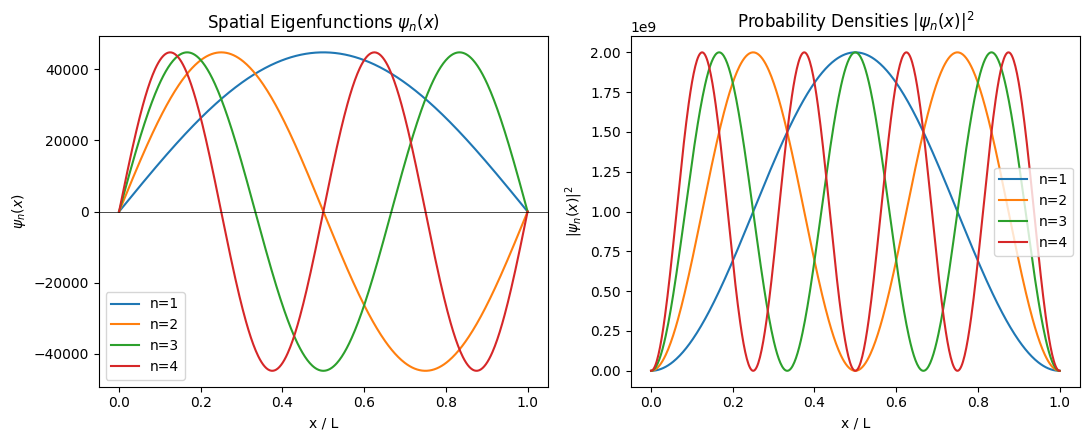

In [3]:
# Spatial eigenfunctions psi_n(x) and probability densities |psi_n(x)|^2
x = np.linspace(0, L, 500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for n in range(1, 5):
  axes[0].plot(x / L, psi_n(x, n), label=f'n={n}')
  axes[1].plot(x / L, psi_n(x, n) ** 2, label=f'n={n}')

axes[0].set_title(r'Spatial Eigenfunctions $\psi_n(x)$')
axes[0].set_xlabel('x / L')
axes[0].set_ylabel(r'$\psi_n(x)$')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].legend()

axes[1].set_title(r'Probability Densities $|\psi_n(x)|^2$')
axes[1].set_xlabel('x / L')
axes[1].set_ylabel(r'$|\psi_n(x)|^2$')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Numerical Verification of Orthonormality

Orthonormality demands that:

$$\int_{0}^{L}\psi_{n}(x)\psi_{m}(x)dx=\delta_{nm}$$
This property is validated numerically using trapezoidal integration across a 4000-point grid.

### Results & Discussion
* **Numerical Matrix:** Integration results yield $1.000$ along the diagonal ($n=m$) and $0.000$ for off-diagonal terms ($n\neq m$).
* **Discussion:** Confirming orthonormality ensures that any arbitrary initial wave packet can be uniquely expanded in terms of these basis states.


Overlap matrix <psi_n | psi_m> (rounded to 3 dp):
[[ 1.  0. -0.  0.  0. -0.]
 [ 0.  1.  0.  0.  0. -0.]
 [-0.  0.  1.  0. -0.  0.]
 [ 0.  0.  0.  1.  0.  0.]
 [ 0.  0. -0.  0.  1.  0.]
 [-0. -0.  0.  0.  0.  1.]]


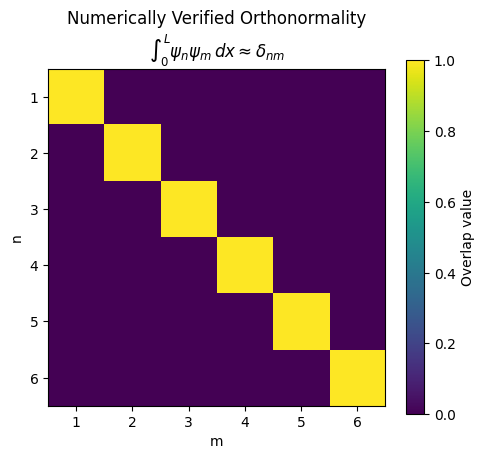

In [4]:
#Numerical verification of orthonormality: <psi_n | psi_m>
N = 6
x_fine = np.linspace(0, L, 4000)
overlap = np.zeros((N, N))

for i in range(1, N + 1):
  for j in range(1, N + 1):
    integrand = psi_n(x_fine, i) * psi_n(x_fine, j)
    overlap[i - 1, j - 1] = np.trapezoid(integrand, x_fine)

print('Overlap matrix <psi_n | psi_m> (rounded to 3 dp):')
print(np.round(overlap, 3))

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(overlap, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(N))
ax.set_xticklabels(range(1, N + 1))
ax.set_yticks(range(N))
ax.set_yticklabels(range(1, N + 1))
ax.set_xlabel('m')
ax.set_ylabel('n')
ax.set_title(
    'Numerically Verified Orthonormality\n'
    r'$\int_0^L \psi_n\psi_m\,dx \approx \delta_{nm}$'
)
plt.colorbar(im, ax=ax, label='Overlap value')
plt.tight_layout()
plt.show()

## 5. Superposition State and Fourier Coefficients
An initial localized Gaussian wave packet $\Psi(x,0)$ centered at $x=L/4$ is decomposed into Fourier coefficients using:

$$c_{n}=\int_{0}^{L}\Psi(x,0)\sqrt{\frac{2}{L}}\sin\!\left(\frac{n\pi x/L}{L}\right)dx$$

### Results & Discussion
* **Normalization Check:** The sum of probability weights $\sum_{n=1}^{40} |c_n|^2 = 1.00000$, satisfying Parseval's theorem.
* **Reconstruction:** A 40-mode sum matches the original input wave packet profile.
* **Weight Distribution:** The lowest energy modes ($n=1, 2, 3$) hold most of the total probability amplitude.


Sum of |c_n|^2 over 40 modes = 1.00000 (should be close to 1)


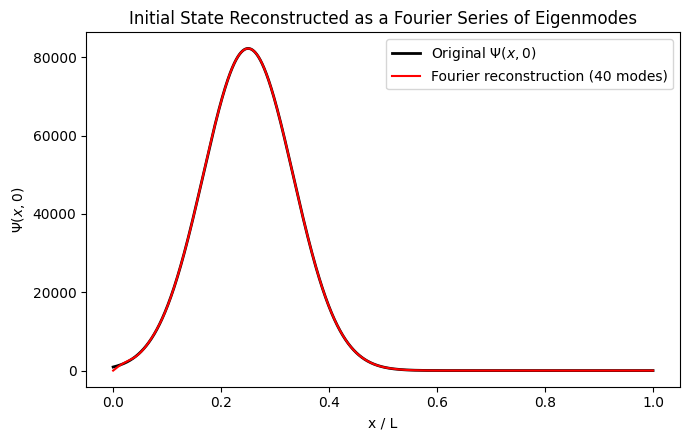

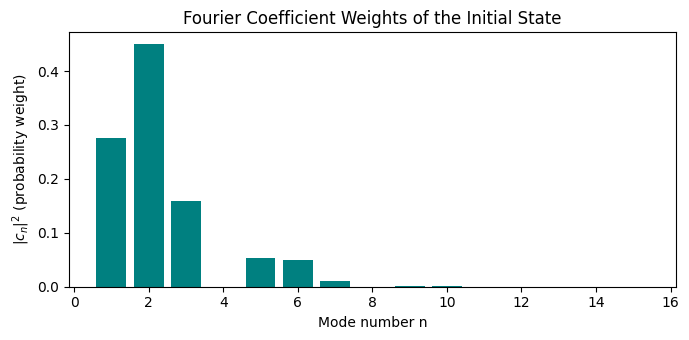

In [6]:
# Construct an initial wave packet, project onto eigenbasis, and reconstruct it as a finite Fourier series
x0 = L / 4  # initial packet centred near the left of the well
sigma = L / 12  # packet width


def psi_initial_unnormalized(x):
  return np.exp(-((x - x0) ** 2) / (2 * sigma**2))


# Normalize numerically so that integral of psi(x,0)^2 dx = 1
x_grid = np.linspace(0, L, 4000)
raw = psi_initial_unnormalized(x_grid)
norm = np.sqrt(np.trapezoid(raw**2, x_grid))
psi0 = raw / norm

# Project onto the first N modes eigenfunctions
N_modes = 40
n_list = np.arange(1, N_modes + 1)
c_n = np.array([np.trapezoid(psi0 * psi_n(x_grid, n), x_grid) for n in n_list])

print(
    f'Sum of |c_n|^2 over {N_modes} modes = {np.sum(c_n**2):.5f} (should be'
    ' close to 1)'
)

# Reconstruct psi(x,0) from the finite Fourier series
psi_reconstructed = np.zeros_like(x_grid)
for n, c in zip(n_list, c_n):
  psi_reconstructed += c * psi_n(x_grid, n)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_grid / L, psi0, 'k', linewidth=2, label=r'Original $\Psi(x,0)$')
ax.plot(
    x_grid / L,
    psi_reconstructed,
    'r',
    linewidth=1.5,
    label=f'Fourier reconstruction ({N_modes} modes)',
)
ax.set_xlabel('x / L')
ax.set_ylabel(r'$\Psi(x,0)$')
ax.set_title('Initial State Reconstructed as a Fourier Series of Eigenmodes')
ax.legend()
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 3.5))
ax2.bar(n_list[:15], c_n[:15] ** 2, color='teal')
ax2.set_xlabel('Mode number n')
ax2.set_ylabel(r'$|c_n|^2$ (probability weight)')
ax2.set_title('Fourier Coefficient Weights of the Initial State')
plt.tight_layout()
plt.show()

## 6. Time Evolution of the Superposition State

Time propagation is modeled by applying state-dependent phase factors:

$$\Psi(x,t)=\sum_{n=1}^{N}c_{n}\psi_{n}(x)e^{-iE_{n}t/\hbar}$$

### Results & Discussion
* **Dynamic Wave Motion:** The probability density $|\Psi(x,t)|^2$ changes continuously with time.
* **Phase Dispersion:** Because $E_n \propto n^2$, component phases evolve at different rates, causing wave packet spreading, oscillation between boundaries, and interference patterns on femtosecond scales ($0\text{ to }5\text{ fs}$).


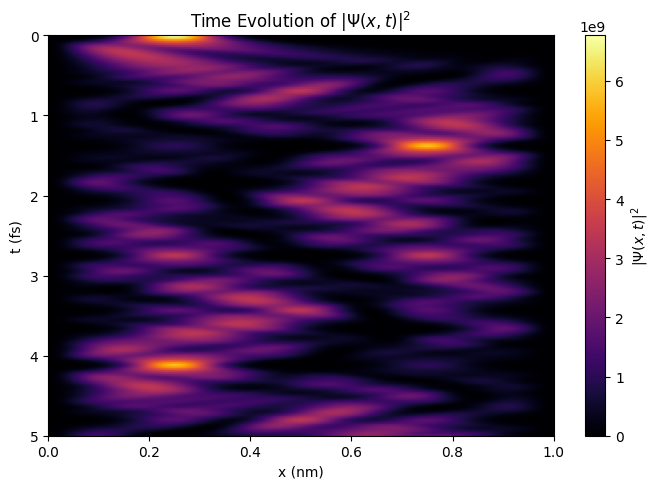

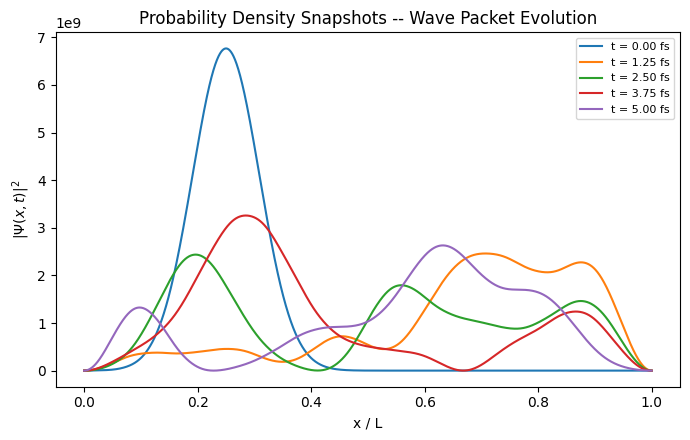

In [7]:
#Time evolution of the superposition state
t_max = 5e-15  # 5 femtoseconds
n_times = 200
t_array = np.linspace(0, t_max, n_times)

X, T = np.meshgrid(x_grid, t_array)
Psi_xt = np.zeros_like(X, dtype=complex)

for n, c in zip(n_list, c_n):
  En = energy_level(n)
  Psi_xt += c * psi_n(X, n) * np.exp(-1j * En * T / hbar)

prob_density = np.abs(Psi_xt) ** 2

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(
    prob_density,
    extent=[0, L * 1e9, t_max * 1e15, 0],
    aspect='auto',
    cmap='inferno',
)
ax.set_xlabel('x (nm)')
ax.set_ylabel('t (fs)')
ax.set_title(r'Time Evolution of $|\Psi(x,t)|^2$')
plt.colorbar(im, ax=ax, label=r'$|\Psi(x,t)|^2$')
plt.tight_layout()
plt.show()

# Snapshot line plots at a few instants
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
snap_times = [0, t_max * 0.25, t_max * 0.5, t_max * 0.75, t_max]

for st in snap_times:
  Psi_t = np.zeros_like(x_grid, dtype=complex)
  for n, c in zip(n_list, c_n):
    En = energy_level(n)
    Psi_t += c * psi_n(x_grid, n) * np.exp(-1j * En * st / hbar)
  ax2.plot(x_grid / L, np.abs(Psi_t) ** 2, label=f't = {st * 1e15:.2f} fs')

ax2.set_xlabel('x / L')
ax2.set_ylabel(r'$|\Psi(x,t)|^2$')
ax2.set_title('Probability Density Snapshots -- Wave Packet Evolution')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Confinement-Length Dependence
Ground-state energy $E_1$ is evaluated across varying well widths $L$ to test the inverse-square relation $E_{n}\propto 1/L^{2}$.

### Results & Discussion
* **Numerical Data:**
  * $L = 0.5\text{ nm} \implies E_1 = 1.5041\text{ eV}$
  * $L = 1.0\text{ nm} \implies E_1 = 0.3760\text{ eV}$
  * $L = 2.0\text{ nm} \implies E_1 = 0.0940\text{ eV}$
  * $L = 5.0\text{ nm} \implies E_1 = 0.0150\text{ eV}$
  * $L = 10.0\text{ nm} \implies E_1 = 0.0038\text{ eV}$
  * $L = 50.0\text{ nm} \implies E_1 = 0.0002\text{ eV}$
* **Discussion:** A log-log plot gives a straight line with a slope of $-2$. Decreasing the confinement width by 10 increases allowed energy levels by 100, demonstrating how physical size controls electronic state spacing in nanostructures.


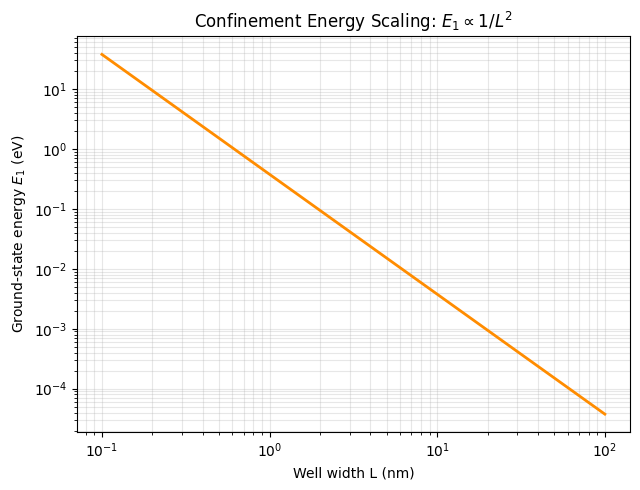

  L (nm) |  E1 (eV)
----------------------
    0.5 |   1.5041
    1.0 |   0.3760
    2.0 |   0.0940
    5.0 |   0.0150
   10.0 |   0.0038
   50.0 |   0.0002


In [8]:
#Ground-state energy vs confinement length L (E1 ~ 1/L^2 scaling)
L_values = np.logspace(-10, -7, 100)  # 0.1 nm to 100 nm
E1_values = energy_level(1, L=L_values) / eV

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.loglog(L_values * 1e9, E1_values, color='darkorange', linewidth=2)
ax.set_xlabel('Well width L (nm)')
ax.set_ylabel('Ground-state energy $E_1$ (eV)')
ax.set_title(r'Confinement Energy Scaling: $E_1 \propto 1/L^2$')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print('  L (nm) |  E1 (eV)')
print('-' * 22)
for L_nm in [0.5, 1, 2, 5, 10, 50]:
  L_test = L_nm * 1e-9
  print(f'{L_nm:7.1f} | {energy_level(1, L=L_test)/eV:8.4f}')

## 8. Conclusion & Engineering Implications
1. **Quantization Control:** Geometric spatial boundary conditions convert continuous energy spectra into discrete allowed energy states.
2. **Device Design Lever ($1/L^2$ Scaling):** The inverse-square dependence on length allows precise tuning of optical absorption and emission characteristics in quantum dots and lasers by altering physical dimensions.
3. **Predictable Wave Dynamics:** Orthonormal state expansion allows accurate simulation of wave packet dynamics and state propagation in confined semiconductor geometries.
